<!--TABLE OF CONTENTS-->
Contents:
- [Virtual Environment](#Virtual-Environment)
- [Brief EDA](#Brief-EDA)
- [Google Colab](#Google-Colab)
  - [Setting up the notebook](#Setting-up-the-notebook)
  - [AI Assistants](#AI-Assistants)
  - [Saving & Sharing](#Saving-&-Sharing)
  - [Opening & Uploading/Downloading](#Opening-&-Uploading/Downloading)
  - [Colab Resources](#Colab-Resources)

# Virtual Environment

You should create a virtual environment dedicated to this class, as this prevents conflicts between libraries and their versions when you work in different projects. In order to create the environment, restart your *Anaconda Prompt* and write the following lines:

- `conda create -n ml2026 python=3.12` (creates the environment);
- `conda activate ml2026` (activates it);
- `conda install ipykernel` (allows the execution of python code in jupyter);
- `python -m ipykernel install --user --name=ml2026` (registers the new virtual environment as a kernel in jupyter, ensuring that it can be selected).

Install the packages necessary for this notebook in your environment
- `pip install pandas scikit-learn seaborn`

Once these steps are completed, start jupyter again, and in the "Kernel" tab, select "Change Kernel", and then "ml2026".

# Brief EDA

Before we start, let's import the `pandas` library and check it's version.

In [3]:
import pandas as pd
pd.__version__

'2.3.3'

As we can see, we can check the package version using use the `__version__` attribute. Note that this attribute is not mandatory, so some packages might not have it.

If we wanted to check the python version we are using in the notebook, we can do it as follows:

In [4]:
import sys
sys.version

'3.14.2 | packaged by Anaconda, Inc. | (main, Dec 19 2025, 11:44:48) [MSC v.1929 64 bit (AMD64)]'

or alternatively:

In [5]:
from platform import python_version
python_version()

'3.14.2'

Now, let's test our setup by doing a quick Exploratory Data Analysis of a small dataset. EDA is an important step in the machine learning pipeline, because, before we can build any model, we need to understand the data.
We will be using the Iris dataset, a classical dataset in machine learning and statistics. It is included in `scikit-learn` in the `datasets` module. It contains the data of the measurements of the iris flowers. Each flower is classified as belonging to one of the three species: *setosa*, *versicolor*, or *virginica*. We can load the dataset by calling the `load_iris` function:

In [6]:
from sklearn.datasets import load_iris
dataset = load_iris()

Note: if you want to get help on some function, just type `?` at the end of its name, for example `load_iris?`

Additional note, `Scikit-learn` is also known as `sklearn`.

We can confirm the details of the dataset by the `DESCR` method.

In [7]:
print(dataset.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

The `dataset` object that is returned by `load_iris` is a `Bunch` object, which is very similar to a dictionary. Confirm the type of the object `dataset`, using the method `type`

In [8]:
type(dataset)

sklearn.utils._bunch.Bunch

The contents of the dataset are stored in the variable `dataset`. In this variable, different information is stored:
- `dataset.target_names`: the names of the classes
- `dataset.target`: values of the target variable (class label)
- `dataset.feature_names`: the names of the features
- `dataset.data`: feature values

Print out the names of the target and the features:

In [9]:
print(dataset.target_names)
print(dataset.feature_names)

['setosa' 'versicolor' 'virginica']
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


For easier data analysis, let's convert the dataset into the Pandas DataFrame type.

In [10]:
df = pd.DataFrame(dataset.data)
df.columns = dataset.feature_names

Tip: If you want to rename the columns, you can use `rename` method, for example for a dataframe called `test` with two columns `A` and `B`, we could rename them with `test=test.rename(columns={"A": "a", "B": "c"})`. We generally avoid column names that have white space.

So far we have added the feature to the dataframe, now let's also add the target column:

In [11]:
df['target'] = dataset.target

First, we should look at the entire dataset. Let's check the number of rows in the dataframe and the number of columns, and the data types of each variable. We get all this simply with `info()` method:

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


How many rows does our dataset have? How many columns? What are the column types?

Separately, we could check the dimensions with `shape` and data types with `dtypes`.

In [13]:
df.shape

(150, 5)

In [14]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object

Next, we can check how many values are missing from the our dataset. We can check it by the combination of the `isnull()` and `sum()` methods in pandas: `df.isnull().sum()`

In [15]:
df.isnull()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,False,False,False
148,False,False,False,False,False


In [16]:
df.isnull().sum() # the sum function here assumes True as 1 and False as 0 to perform the computation

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

How many missing values does each column have?

Next, let's see do we have any duplicates with `df[df.duplicated(keep= False)]`. Next, let's see do we have any duplicates with `df[df.duplicated(keep= False)]`. Here, the parameter `keep= False` specifies that it marks all duplicates (and not just the first or the last occurence).

In [17]:
df[df.duplicated()]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
142,5.8,2.7,5.1,1.9,2


In [18]:
df[df.duplicated(keep= False)]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
101,5.8,2.7,5.1,1.9,2
142,5.8,2.7,5.1,1.9,2


How many duplicate values does our dataset have?

Before we remove duplicate values, we should be sure that there is no special reason for having duplicate values. For example, there could be an issue in the data collection pipeline and we might need to investigate it further. If we are sure that we do not need to keep track of the duplicate values, we remove them with `drop_duplicates()` .

In [19]:
df = df.drop_duplicates() #only the row 142 is removed because keep=False was not specified
#df.drop_duplicates(inplace=True) would also work

Check the number of data points now present in the dataset.

In [20]:
df.shape

(149, 5)

How many instances we have for each value of target, i.e., how many rows we have per each iris species? We can check this with `value_counts()` method.

In [21]:
df['target'].value_counts()

target
0    50
1    50
2    49
Name: count, dtype: int64

Next, we can calculate the basic descriptive statistics values of all numerical variables with a single method: `describe()`

In [22]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,149.000000,149.000000,149.000000,149.000000,149.000000
mean,5.843624,3.059732,3.748993,1.194631,0.993289
std,0.830851,0.436342,1.767791,0.762622,0.817847
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.300000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


Now, let's visualize our data.  For this we will import visualization library `seaborn`.

In [23]:
import seaborn as sns

We will plot the histograms of all the columns.

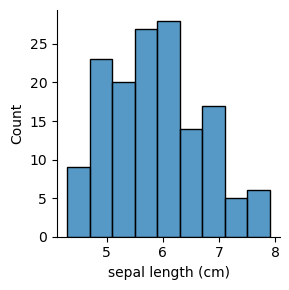

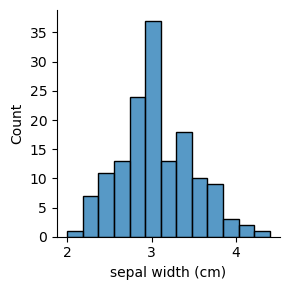

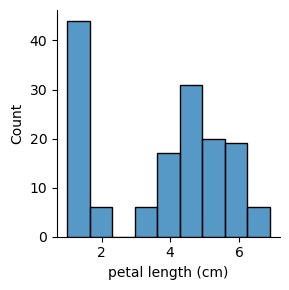

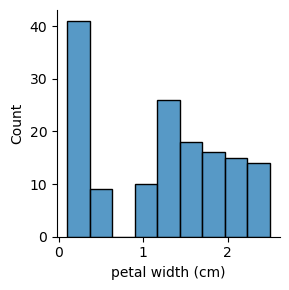

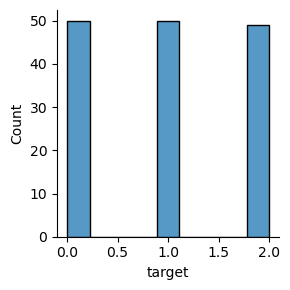

In [24]:
for col in df.columns:
    sns.displot(df[col] , height=3)

We can also visualize the relationship between all the numerical variables, for each of the target values with a single line of code.

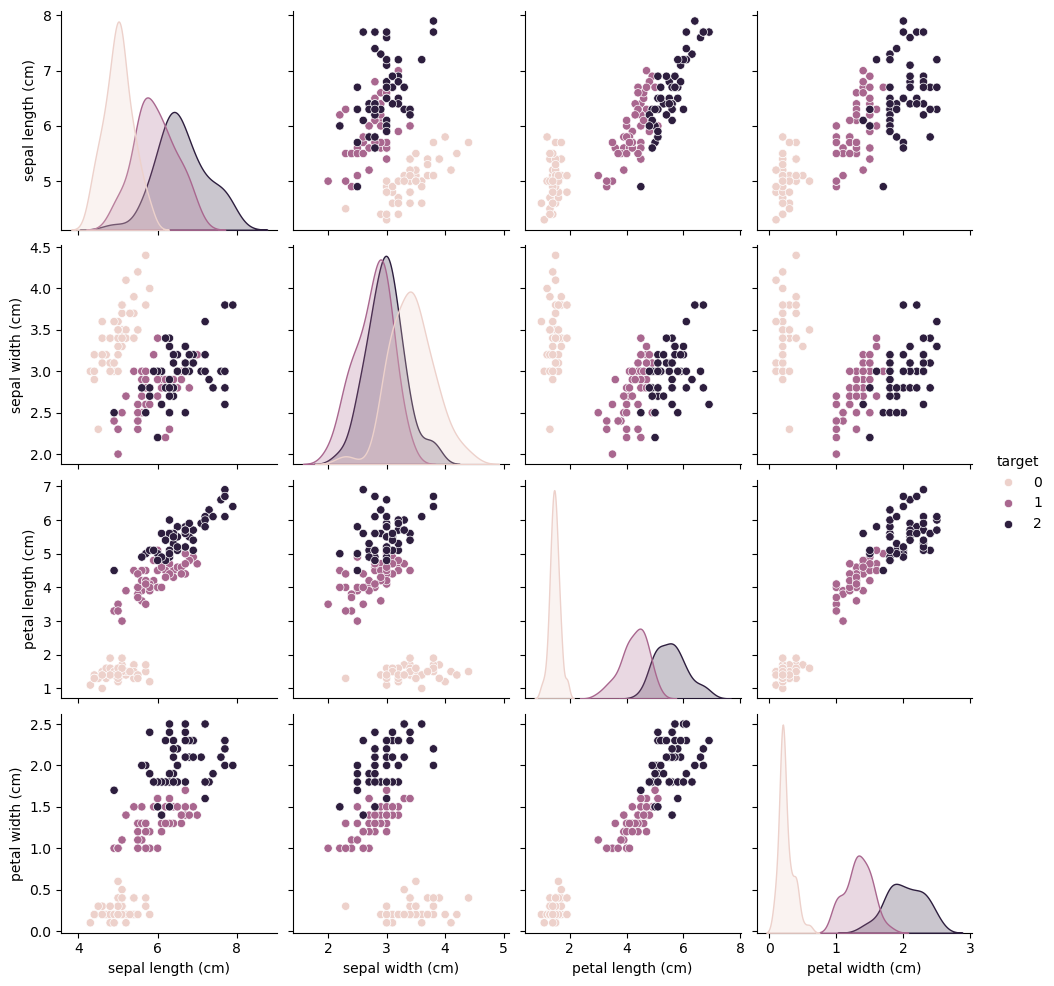

In [25]:
sns.pairplot(df, hue='target', height=2.5)

## Practice Question

Now, can you repeat these steps for a real-world dataset called the Boston Housing dataset? It can be loaded from `sklearn` module `dataset` using `load_boston`.

# Google Colab

Google Colab is a free jupyter notebook environment that runs in the cloud. This enables you to work in real-time with your colleagues on the same notebook.

## Setting up the notebook

To access Colab, simply  click on the link: https://colab.research.google.com/

Now, you can also mount the drive in google colab to easily access data.  

In the vertical left bar on the left, click on the second last symbol indicating "Files"; then, you can click on the third symbol that denotes "Mount Drive".

After a few moments, you be able to check your drive in google colab and you can move the files in the folders as you wish.

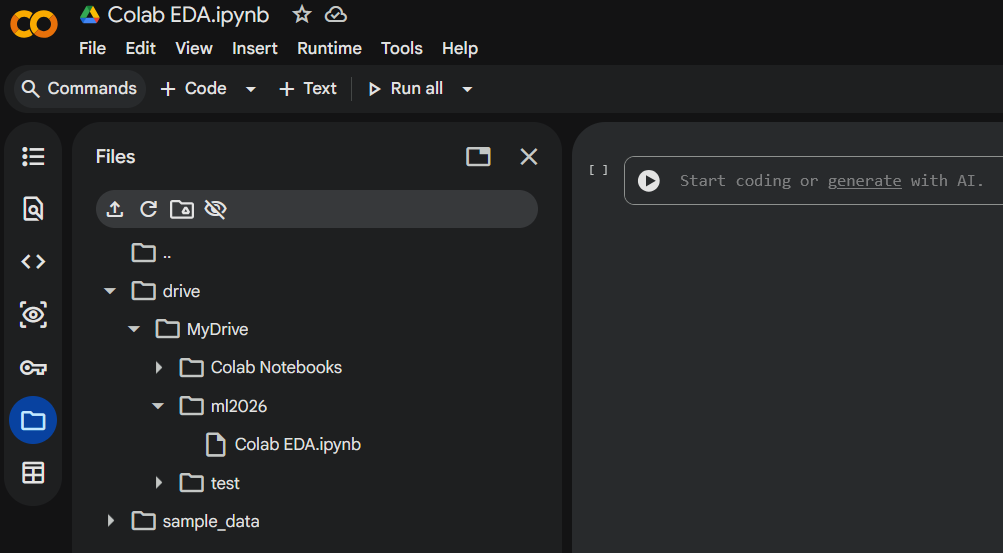

Colab may also prompt you to run the following code, which achieves the same result:

In [26]:
#from google.colab import drive
#drive.mount('/content/drive')

In order to create a folder for the course, simply right-click on "MyDrive", create folder, and write "ml2026". Similarly, uploading notebooks to it only entails right-clicking on the new folder and selecting "Upload".

Additionally, you can peruse the contents in the ml2026 folder by running this line (which is empty at the moment):

In [27]:
#!ls "/content/drive/My Drive/ml2026"

During the course, data will often be imported to Google Colab and read via *read_csv*. As this folder will be available in the drive, datasets can be also be uploaded there. When reading these datasets from Google Colab, the path on which the file is located must be provided, and the code will follow this pattern:

- `path = '/content/drive/MyDrive/ml2026/file_name.csv'`
- `df = pd.read_csv(path)`

## AI Assistants

In any new cell, there's an option to generate code. Let's click on it and write "import the iris dataset and explore the data".

What happened? The AI assistant may generate different results, but it is likely that the code generated is similar to what was performed before.

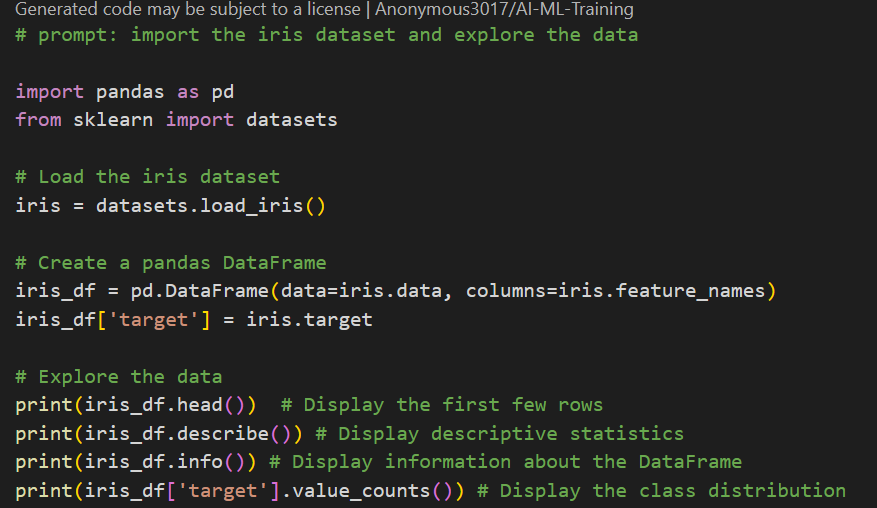

Create a new cell below, and generate code again. This time, write "I would like to see simple visualizations as well".

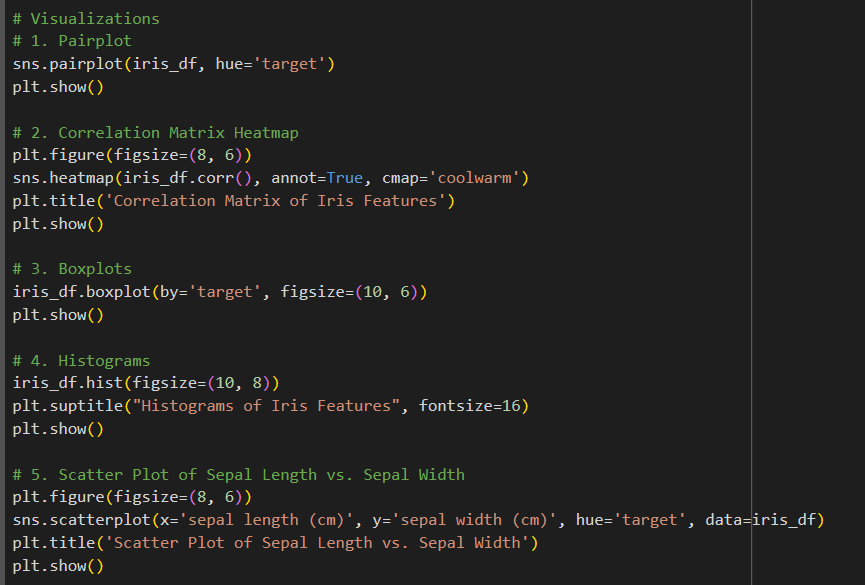

The AI Assistant (Gemini) followed the instructions, but suppose you are not sure of what it means. On the upper right corner of the current cell, click on the third option (Available AI Features), and select "Explain Code".

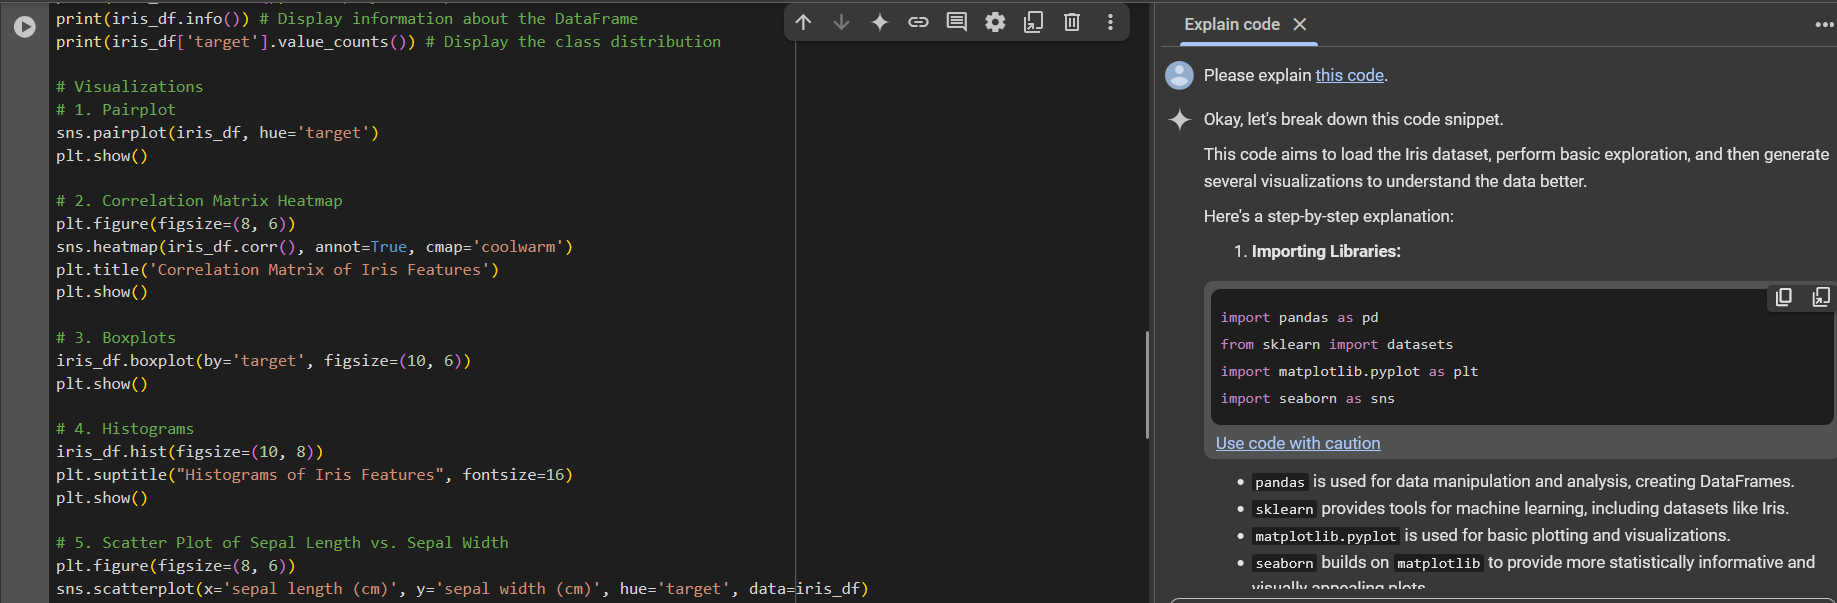

Gemini explained each of the steps in-depth, but imagine that you're not sure how to interpret the results of the visualizations. In the same Gemini window, enter the prompt "could you extract conclusions from the plots?"

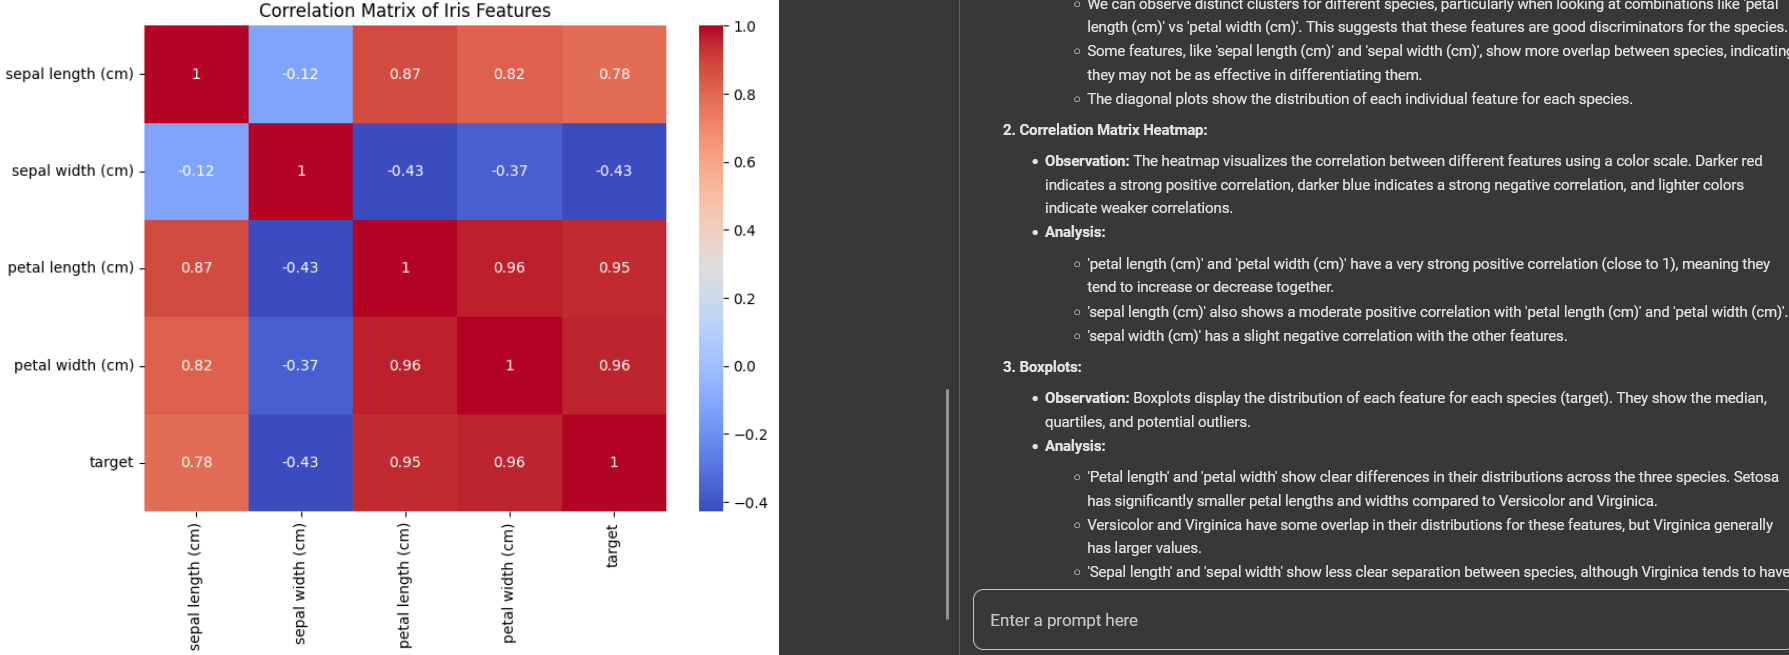

As you can see, AI Assistants are a valuable tool for data scientists.

Please note that, although this and other AI Assistants like ChatGPT have seen significant advancements, they should be used with caution. Throughout the course, **the use of such technologies is allowed, but solely as a supportive tool, and not as a substitute. Any code or conclusions generated with an AI Assistant must be verified and understood.**

## Saving & Sharing

Once you have stopped coding in colab, you can select "File" and "Save" in the upper left corner to save your work.

If you'd like to share you notebook with your colleagues, you can select "Share" in the upper right corner of colab, enter the e-mails, ensure "Editor" is selected, write a notifying message, and send them the sharing information (optionally, you can copy the link via the bottom left icon to share manually as well).

It is also possible to share through google drive: simply locate the notebook on the drive, click on the three dots on the right of the file, select share and follow the outlined steps.

## Opening & Uploading/Downloading

When you'd like to return to colab and continue your work, you can select "File" in the upper left corner, "Open notebook", and choose the sought-after file to resume coding.

In addition, you can upload local files directly to your colab through "File" and "Upload notebook"; this will save the file in your default google drive location "Colab Notebooks", but you can move it to any folder in the drive itself, or through colab by mounting the drive first, as previously mentioned.

You may also download your current colab notebook to your computer by going to "File", "Download", and "Download .ipynb".

In Colab, the left-hand sidebar represents the local runtime environment. While mounting your drive makes the files visible there so your code can reach them, the interface doesn't treat .ipynb files (i.e., notebooks) in that sidebar as executable documents; hence, these cannot be opened directly via double-click or right-click options.

As such, opening files can be done through "File" in the upper right corner as mentioned, or by navigating to google drive, finding the newly created ml2026 folder, right-clicking the sought-after file, and selecting "Open with" then Google Colaboratory. This tends to be a swifter option to open notebooks.

## Colab Resources

You can run any code either through local (CPU) or Colab  (GPU/TPU) resources, based on your preference. As Colab allows a limited use of GPUs (can be selected by going to Runtime and choosing "Changing runtime type"), this can be useful for running the code pertaining to, for instance, neural networks.



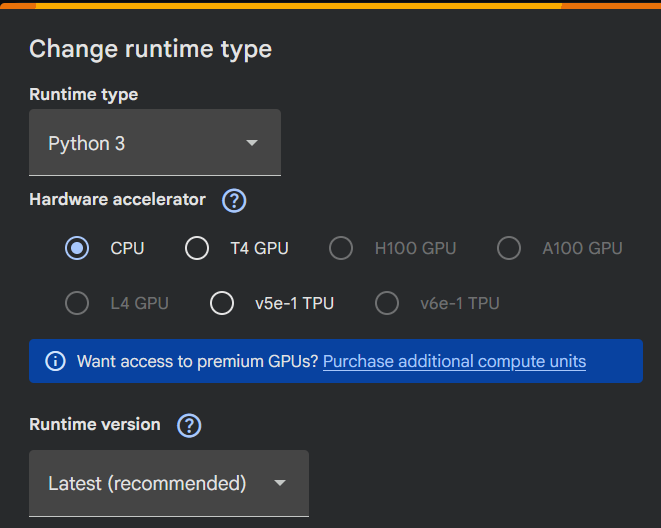